# 01 · Data pipeline & exploratory analysis (D1, D2)

Project FORESIGHT · NorthBay Living · Zidio Development Data Science internship · Eswar Mahalingam

In [1]:
import sys, json, pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
from IPython.display import Image, display

## 1. Run the reproducible pipeline
Every cleaning decision is coded in `src/pipeline.py` and logged with its rationale.

In [2]:
import pipeline
pipeline.main()

Pipeline complete.
{
  "forecast_origin": "2025-11-30",
  "skus": 50,
  "weeks": 104,
  "first_week": "2024-01-07",
  "last_week": "2025-12-28",
  "holdout_weeks": 4,
  "total_units": 510082,
  "total_revenue": 3085562054.8100004,
  "unmapped_inventory_skus": 150,
  "unmapped_inventory_value_latest": 174874618.36
}
- [Stock_data.csv] Unrelated file: equity price history (AABA ticker 2006–2017) (n=None) → Excluded from the pipeline
- [sales_daily] Duplicate (date, sku) rows (n=0) → None found — no action
- [sales_daily] Negative units_sold (returns?) (n=0) → None found — no action
- [sales_daily] Missing numeric values (n=0) → None found — no action
- [sales_daily] revenue != units_sold * unit_price (>₹1 gap) (n=0) → None found — internally consistent
- [sales_daily] Rows retained after cleaning (n=36550) → 36550 → 36550
- [sku_master] launch_date AFTER first recorded sale (n=21) → launch_date overridden with first_sale_date (original kept as launch_date_master)
- [sku_master] list_pric

## 2. Data-quality log

In [3]:
dq = json.loads((ROOT/'data/processed/data_quality_log.json').read_text())
pd.DataFrame(dq['issues'])[['table','issue','count','action']]

,table,issue,count,action
0,Stock_data.csv,Unrelated file: equity price history (AABA tic...,NaN,Excluded from the pipeline
1,sales_daily,"Duplicate (date, sku) rows",0.0,None found — no action
2,sales_daily,Negative units_sold (returns?),0.0,None found — no action
3,sales_daily,Missing numeric values,0.0,None found — no action
4,sales_daily,revenue != units_sold * unit_price (>₹1 gap),0.0,None found — internally consistent
5,sales_daily,Rows retained after cleaning,36550.0,36550 → 36550
6,sku_master,launch_date AFTER first recorded sale,21.0,launch_date overridden with first_sale_date (o...
7,sku_master,list_price below unit_cost (negative gross mar...,16.0,Kept; flagged margin_flag='negative' and surfa...
8,sku_master,category/subcategory pairs that look inconsist...,40.0,Kept the master 'category' for reporting; adde...
9,inventory_snapshots,SKUs present in inventory but with NO sales hi...,150.0,Excluded from forecasting/risk; listed separat...


## 3. The analysis-ready weekly dataset

In [4]:
wk = pd.read_csv(ROOT/'data/processed/sales_weekly.csv', parse_dates=['week_end'])
print(wk.shape); wk.head()

(5200, 18)


,sku_id,week_end,units,revenue,promo_days,holiday_days,unit_price,week_of_year,month,year,season,category,subcategory,launch_date,unit_cost,list_price,weeks_since_launch,is_holdout
0,SKU001,2024-01-07,106,388389.30,0,0,3664.05,1,1,2024,Winter,Furniture,Chair,2022-04-09,1758.45,3664.05,91,False
1,SKU001,2024-01-14,85,311444.25,0,0,3664.05,2,1,2024,Winter,Furniture,Chair,2022-04-09,1758.45,3664.05,92,False
2,SKU001,2024-01-21,117,428693.85,0,0,3664.05,3,1,2024,Winter,Furniture,Chair,2022-04-09,1758.45,3664.05,93,False
3,SKU001,2024-01-28,89,326100.45,0,1,3664.05,4,1,2024,Winter,Furniture,Chair,2022-04-09,1758.45,3664.05,94,False
4,SKU001,2024-02-04,119,436021.95,0,0,3664.05,5,2,2024,Winter,Furniture,Chair,2022-04-09,1758.45,3664.05,95,False


## 4. Demand patterns — seasonality, drivers, movers, dead stock
Figures are produced by `src/eda.py` so the memo and the notebook always agree.

In [5]:
import eda
eda.main()

{
  "peak_month": 3,
  "trough_month": 10,
  "peak_vs_trough_pct": 52.25607404550714,
  "weekend_lift_pct": 24.862329465272804,
  "promo_lift_pct": 38.12067723804762,
  "holiday_effect_pct": -13.287805801801367,
  "top10_revenue_share_pct": 47.729850468707774,
  "bottom10_revenue_share_pct": 3.9861411183828444,
  "dead_stock_candidates": [
    "SKU028",
    "SKU048",
    "SKU010",
    "SKU050",
    "SKU011"
  ],
  "skus": 50,
  "n_negative_margin": 16,
  "negative_margin_revenue_share_pct": 16.69237227354079,
  "top_sku": "SKU026"
}


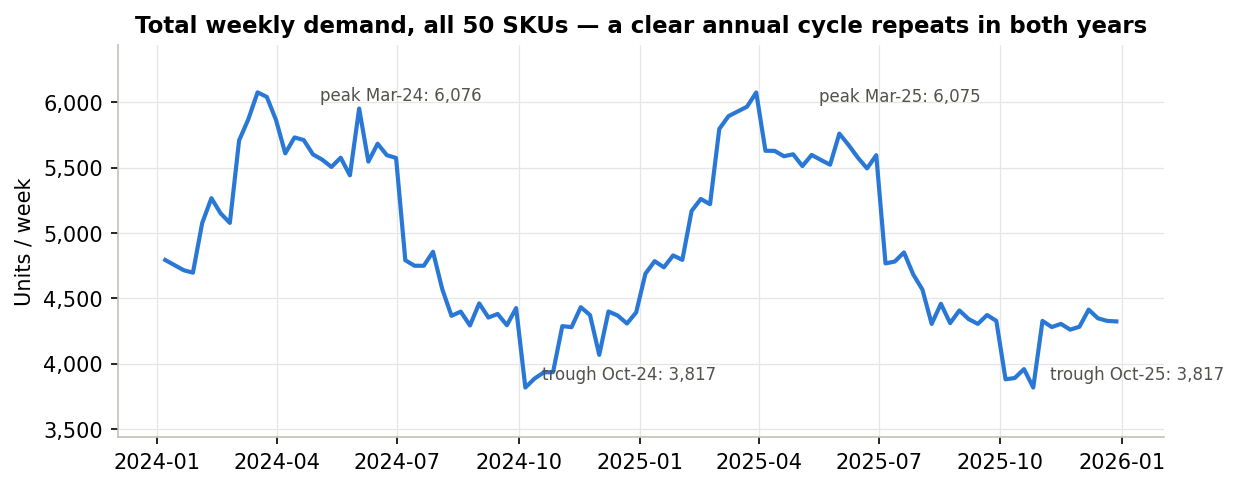

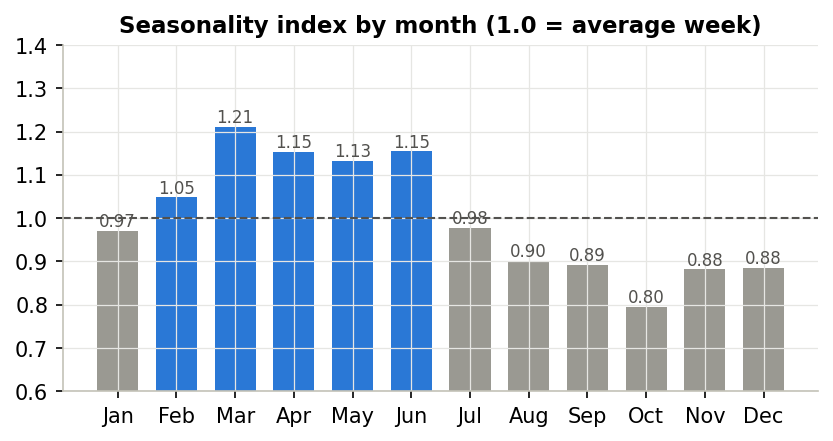

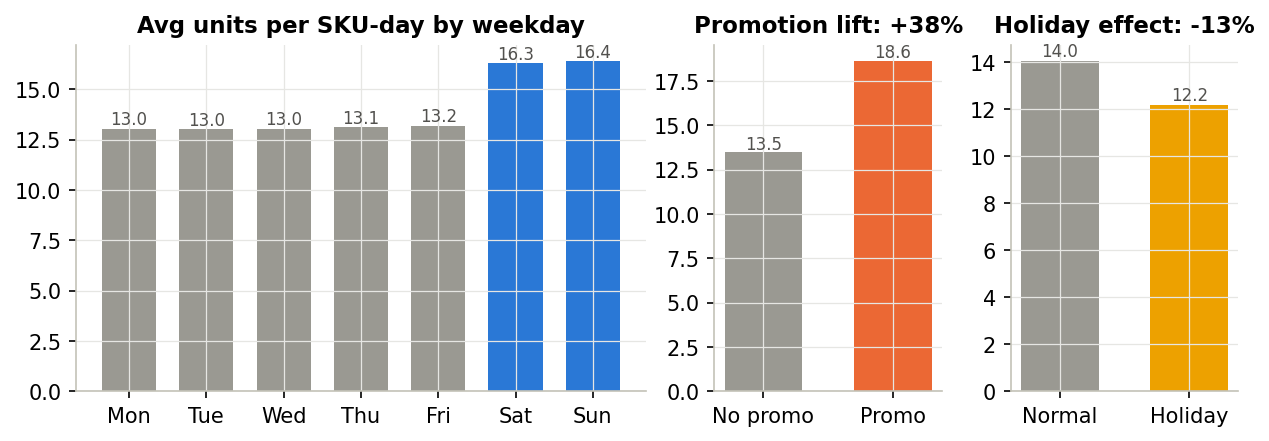

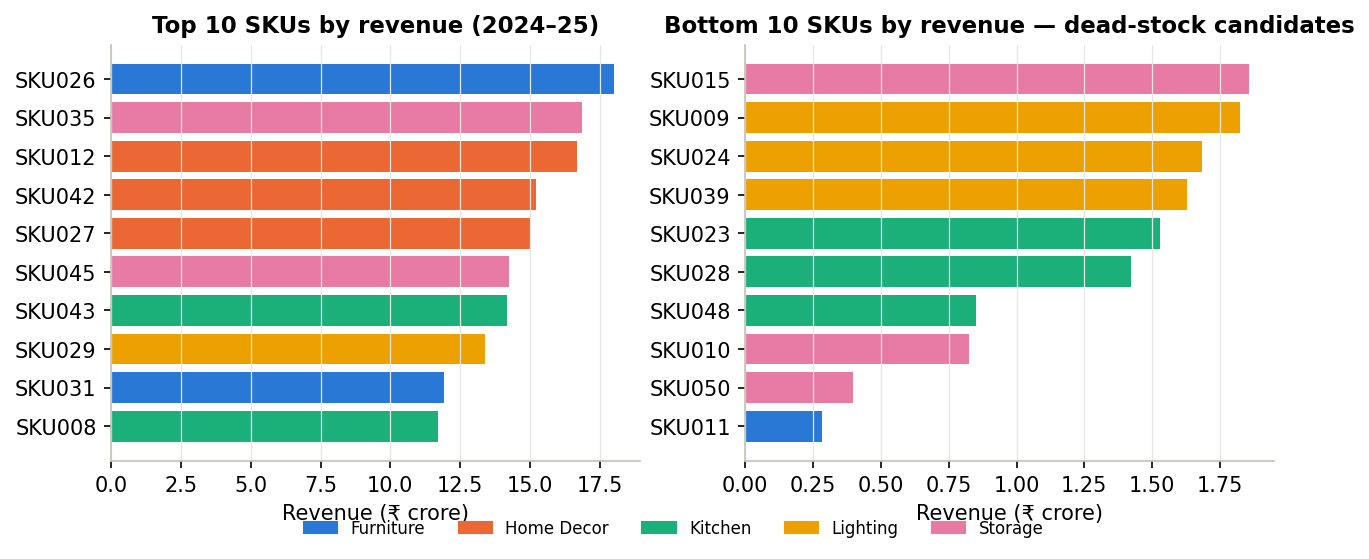

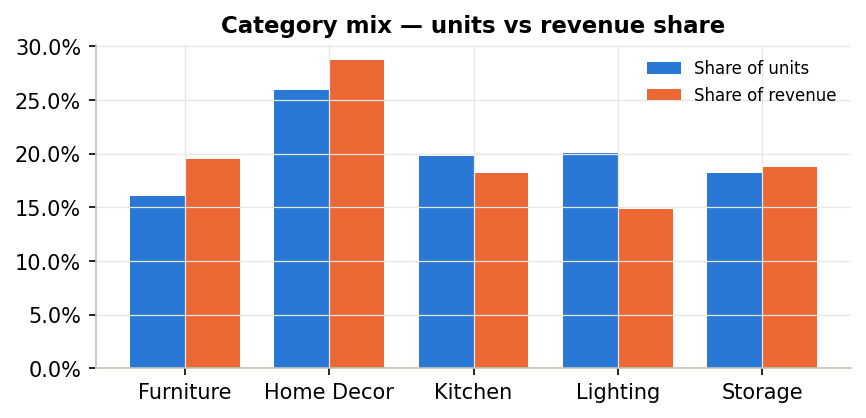

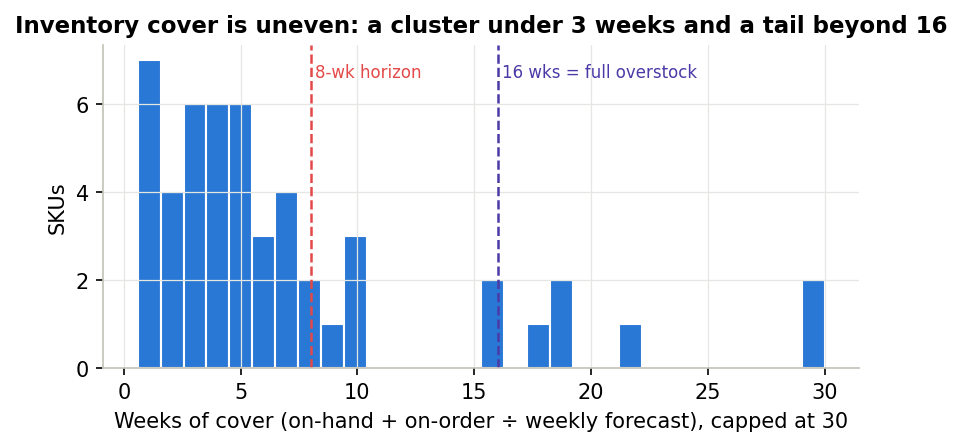

In [6]:
for f in ['01_weekly_demand','02_seasonality_index','03_demand_drivers','04_top_bottom_movers','05_category_mix','11_weeks_of_cover']:
    display(Image(str(ROOT/f'reports/figures/{f}.png'), width=900))

## 5. Three business insights (plain language)
1. **Demand is seasonal, not random.** March sells ~50% more than October in both years; ordering the same quantity every month guarantees stockouts in spring and overstock in autumn.
2. **Promotions and weekends move product.** Promo days sell ~38% more; Saturdays/Sundays ~25% more. Promotions are planned, so they belong in the forecast.
3. **Money is concentrated.** The top 10 SKUs earn ~48% of revenue; the bottom 10 earn ~4% and several are dead-stock candidates. 16 SKUs are priced below cost — a master-data issue Finance must confirm.